# 반품예측 모델 학습 및 평가

전처리 셀은 제거하고, **전처리 완료된 데이터셋**(`X_tr_*`, `X_val_*`, `X_test_*`, `y_tr`, `y_val`)을 바로 불러와서 학습하도록 정리한 버전입니다.

포함 내용:
- XGBoost / LightGBM / CatBoost / LogisticRegression 학습
- 학습 곡선 시각화
- 확장 성능 지표 출력
- 모델 비교표 생성
- 테스트 예측 확률 저장


In [1]:
#! pip install scikit-learn

In [2]:
#! pip install xgboost

In [3]:
#! pip install lightgbm

In [4]:
#! pip install catboost

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, classification_report, log_loss, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef, brier_score_loss
)
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
THRESHOLD = 0.5

# -----------------------------
# 데이터 로드
# -----------------------------
X_train_unscaled = pd.read_csv("X_tr_unscaled.csv")
X_val_unscaled = pd.read_csv("X_val_unscaled.csv")
X_test_unscaled = pd.read_csv("X_test_unscaled.csv")

X_train_scaled = pd.read_csv("X_tr_scaled.csv")
X_val_scaled = pd.read_csv("X_val_scaled.csv")
X_test_scaled = pd.read_csv("X_test_scaled.csv")

y_train = pd.read_csv("y_tr.csv")["returned"]
y_val = pd.read_csv("y_val.csv")["returned"]

print("데이터 로드 완료")
print(f"X_train_unscaled: {X_train_unscaled.shape}")
print(f"X_val_unscaled:   {X_val_unscaled.shape}")
print(f"X_test_unscaled:  {X_test_unscaled.shape}")
print(f"X_train_scaled:   {X_train_scaled.shape}")
print(f"X_val_scaled:     {X_val_scaled.shape}")
print(f"X_test_scaled:    {X_test_scaled.shape}")
print(f"y_train:          {y_train.shape}")
print(f"y_val:            {y_val.shape}")

# 결과 저장용 컨테이너
all_results = []
test_predictions = {}

def evaluate_model(model_name, y_true, y_pred, y_proba):
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "log_loss": log_loss(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

    print(f"\n{'='*70}")
    print(f"{model_name} Validation 결과")
    print(f"{'='*70}")
    for metric_name, metric_value in results.items():
        if metric_name != "model":
            print(f"{metric_name:>18}: {metric_value:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred, zero_division=0))

    return results

def plot_boosting_learning_curve(eval_result, model_name, train_key, valid_key,
                                 train_metric, valid_metric, ylabel):
    plt.figure(figsize=(8, 5))
    plt.plot(eval_result[train_key][train_metric], label=f"train_{ylabel.lower()}")
    plt.plot(eval_result[valid_key][valid_metric], label=f"val_{ylabel.lower()}")
    plt.title(f"{model_name} Learning Curve")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_logistic_learning_curve(model, X, y, scoring="f1"):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label=f"train_{scoring}")
    plt.plot(train_sizes, val_mean, marker="o", label=f"cv_{scoring}")
    plt.title("Logistic Regression Learning Curve")
    plt.xlabel("Training Size")
    plt.ylabel(scoring.upper())
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

데이터 로드 완료
X_train_unscaled: (160000, 26)
X_val_unscaled:   (40000, 26)
X_test_unscaled:  (50000, 26)
X_train_scaled:   (160000, 26)
X_val_scaled:     (40000, 26)
X_test_scaled:    (50000, 26)
y_train:          (160000,)
y_val:            (40000,)


🚀 XGBoost 모델 학습 시작
✅ XGBoost 학습 완료

XGBoost Validation 결과
          accuracy: 0.5646
 balanced_accuracy: 0.5593
         precision: 0.5499
            recall: 0.4555
                f1: 0.4983
           roc_auc: 0.5885
            pr_auc: 0.5556
          log_loss: 0.6803
       brier_score: 0.2436
               mcc: 0.1213

Confusion Matrix
[[13938  7078]
 [10337  8647]]

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.66      0.62     21016
           1       0.55      0.46      0.50     18984

    accuracy                           0.56     40000
   macro avg       0.56      0.56      0.56     40000
weighted avg       0.56      0.56      0.56     40000



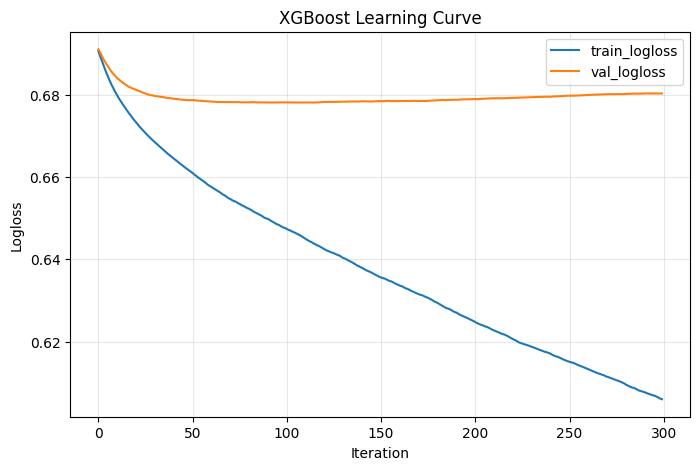

In [6]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric=["logloss", "auc"]
)

print("🚀 XGBoost 모델 학습 시작")
xgb_model.fit(
    X_train_unscaled, y_train,
    eval_set=[(X_train_unscaled, y_train), (X_val_unscaled, y_val)],
    verbose=False
)
print("✅ XGBoost 학습 완료")

xgb_val_proba = xgb_model.predict_proba(X_val_unscaled)[:, 1]
xgb_val_pred = (xgb_val_proba >= THRESHOLD).astype(int)
xgb_test_proba = xgb_model.predict_proba(X_test_unscaled)[:, 1]

all_results.append(evaluate_model("XGBoost", y_val, xgb_val_pred, xgb_val_proba))
test_predictions["XGBoost"] = xgb_test_proba

xgb_eval_result = xgb_model.evals_result()
plot_boosting_learning_curve(
    xgb_eval_result,
    model_name="XGBoost",
    train_key="validation_0",
    valid_key="validation_1",
    train_metric="logloss",
    valid_metric="logloss",
    ylabel="Logloss"
)

🚀 LightGBM 모델 학습 시작
[LightGBM] [Info] Number of positive: 75935, number of negative: 84065
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006009 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1715
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474594 -> initscore=-0.101713
[LightGBM] [Info] Start training from score -0.101713
✅ LightGBM 학습 완료

LightGBM Validation 결과
          accuracy: 0.5673
 balanced_accuracy: 0.5612
         precision: 0.5557
            recall: 0.4406
                f1: 0.4915
           roc_auc: 0.5927
            pr_auc: 0.5599
          log_loss: 0.6781
       brier_score: 0.2426
               mcc: 0.1262

Confusion Matrix
[[14329  6687]
 [10620  8364]]

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.68      0.62    

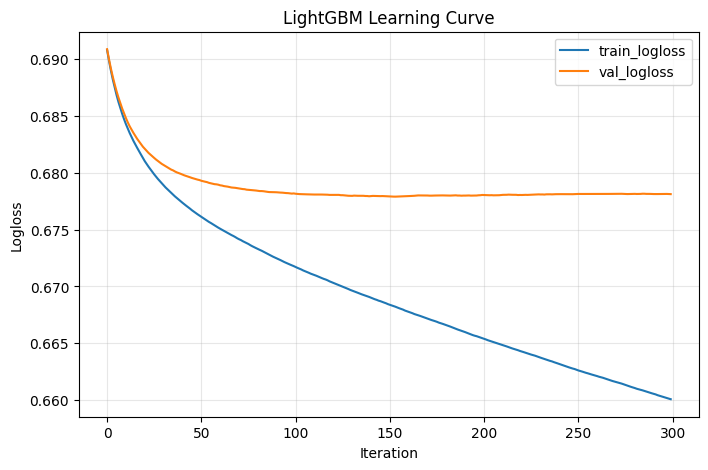

In [7]:
# LightGBM
lgb_model = LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("🚀 LightGBM 모델 학습 시작")
lgb_model.fit(
    X_train_unscaled, y_train,
    eval_set=[(X_train_unscaled, y_train), (X_val_unscaled, y_val)],
    eval_metric=["binary_logloss", "auc"]
)
print("✅ LightGBM 학습 완료")

lgb_val_proba = lgb_model.predict_proba(X_val_unscaled)[:, 1]
lgb_val_pred = (lgb_val_proba >= THRESHOLD).astype(int)
lgb_test_proba = lgb_model.predict_proba(X_test_unscaled)[:, 1]

all_results.append(evaluate_model("LightGBM", y_val, lgb_val_pred, lgb_val_proba))
test_predictions["LightGBM"] = lgb_test_proba

lgb_eval_result = lgb_model.evals_result_
plot_boosting_learning_curve(
    lgb_eval_result,
    model_name="LightGBM",
    train_key="training",
    valid_key="valid_1",
    train_metric="binary_logloss",
    valid_metric="binary_logloss",
    ylabel="Logloss"
)

🚀 CatBoost 모델 학습 시작
✅ CatBoost 학습 완료

CatBoost Validation 결과
          accuracy: 0.5684
 balanced_accuracy: 0.5622
         precision: 0.5572
            recall: 0.4407
                f1: 0.4922
           roc_auc: 0.5940
            pr_auc: 0.5604
          log_loss: 0.6778
       brier_score: 0.2424
               mcc: 0.1283

Confusion Matrix
[[14368  6648]
 [10617  8367]]

Classification Report
              precision    recall  f1-score   support

           0       0.58      0.68      0.62     21016
           1       0.56      0.44      0.49     18984

    accuracy                           0.57     40000
   macro avg       0.57      0.56      0.56     40000
weighted avg       0.57      0.57      0.56     40000



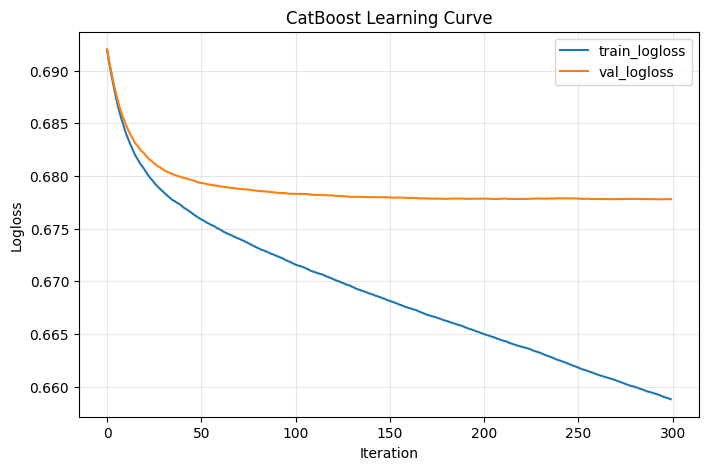

In [8]:
# CatBoost
cat_model = CatBoostClassifier(
    iterations=300,
    depth=8,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False
)

print("🚀 CatBoost 모델 학습 시작")
cat_model.fit(
    X_train_unscaled, y_train,
    eval_set=(X_val_unscaled, y_val),
    use_best_model=True,
    verbose=False
)
print("✅ CatBoost 학습 완료")

cat_val_proba = cat_model.predict_proba(X_val_unscaled)[:, 1]
cat_val_pred = (cat_val_proba >= THRESHOLD).astype(int)
cat_test_proba = cat_model.predict_proba(X_test_unscaled)[:, 1]

all_results.append(evaluate_model("CatBoost", y_val, cat_val_pred, cat_val_proba))
test_predictions["CatBoost"] = cat_test_proba

cat_eval_result = cat_model.get_evals_result()
plot_boosting_learning_curve(
    cat_eval_result,
    model_name="CatBoost",
    train_key="learn",
    valid_key="validation",
    train_metric="Logloss",
    valid_metric="Logloss",
    ylabel="Logloss"
)

🚀 LogisticRegression 모델 학습 시작
✅ LogisticRegression 학습 완료

LogisticRegression Validation 결과
          accuracy: 0.5656
 balanced_accuracy: 0.5591
         precision: 0.5544
            recall: 0.4315
                f1: 0.4853
           roc_auc: 0.5876
            pr_auc: 0.5541
          log_loss: 0.6797
       brier_score: 0.2434
               mcc: 0.1223

Confusion Matrix
[[14431  6585]
 [10792  8192]]

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.69      0.62     21016
           1       0.55      0.43      0.49     18984

    accuracy                           0.57     40000
   macro avg       0.56      0.56      0.55     40000
weighted avg       0.56      0.57      0.56     40000



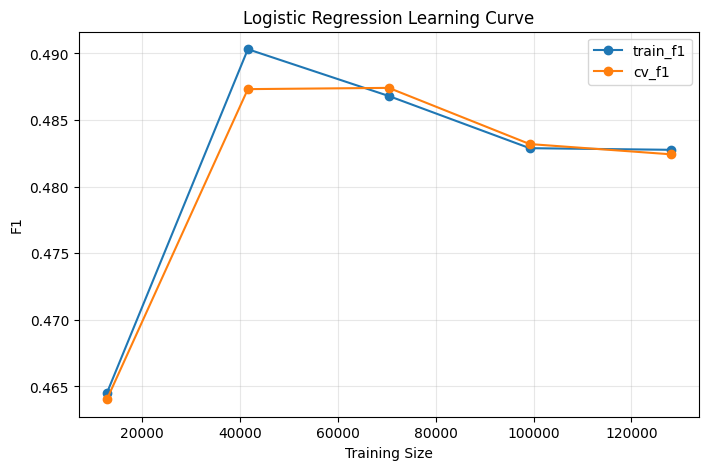

In [9]:
# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

print("🚀 LogisticRegression 모델 학습 시작")
lr_model.fit(X_train_scaled, y_train)
print("✅ LogisticRegression 학습 완료")

lr_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_val_pred = (lr_val_proba >= THRESHOLD).astype(int)
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

all_results.append(evaluate_model("LogisticRegression", y_val, lr_val_pred, lr_val_proba))
test_predictions["LogisticRegression"] = lr_test_proba

plot_logistic_learning_curve(lr_model, X_train_scaled, y_train, scoring="f1")

In [10]:
# 모델 비교표
results_df = pd.DataFrame(all_results).sort_values(
    by=["roc_auc", "f1", "pr_auc"],
    ascending=False
).reset_index(drop=True)

print("=== 모델 비교표 ===")
display(results_df)

# 테스트 예측 확률 DataFrame
test_pred_proba_df = pd.DataFrame(test_predictions)
print("\n=== 테스트 예측 확률 미리보기 ===")
display(test_pred_proba_df.head())

# 필요 시 저장
results_df.to_csv("model_comparison_metrics.csv", index=False)
test_pred_proba_df.to_csv("test_pred_proba_by_model.csv", index=False)

print("\n저장 완료:")
print("- model_comparison_metrics.csv")
print("- test_pred_proba_by_model.csv")

=== 모델 비교표 ===


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,brier_score,mcc
0,CatBoost,0.568375,0.562205,0.557243,0.440740,0.492191,0.594016,0.560389,0.677778,0.242427,0.128298
1,LightGBM,0.567325,0.561198,0.555711,0.440582,0.491494,0.592733,0.559921,0.678129,0.242598,0.126161
2,XGBoost,0.564625,0.559349,0.549889,0.455489,0.498257,0.588530,0.555634,0.680312,0.243612,0.121349
3,LogisticRegression,0.565575,0.559094,0.554375,0.431521,0.485294,0.587567,0.554094,0.679722,0.243371,0.122279



=== 테스트 예측 확률 미리보기 ===


,XGBoost,LightGBM,CatBoost,LogisticRegression
0,0.473554,0.464200,0.454928,0.441991
1,0.538314,0.464703,0.507492,0.493221
2,0.427689,0.453101,0.489715,0.438998
3,0.610243,0.610765,0.631536,0.584792
4,0.392014,0.419245,0.431416,0.452975



저장 완료:
- model_comparison_metrics.csv
- test_pred_proba_by_model.csv
